<a href="https://colab.research.google.com/github/bryanhulu/DW-A-Tugas3/blob/main/Proyek_BnB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

          TABEL PERBANDINGAN AKURASI AKHIR               
1. Linear Regression (Konversi)  : 0.8300 (83.0%)
2. K-Nearest Neighbors (KNN)     : 0.7800 (78.0%)
3. Decision Tree                 : 0.7300 (73.0%)

=== KLASIFIKASI REPORT: LINEAR REGRESSION (KONVERSI) ===
              precision    recall  f1-score   support

           0       0.76      0.74      0.75        70
           1       0.86      0.88      0.87       130

    accuracy                           0.83       200
   macro avg       0.81      0.81      0.81       200
weighted avg       0.83      0.83      0.83       200


=== KLASIFIKASI REPORT: K-NEAREST NEIGHBORS ===
              precision    recall  f1-score   support

           0       0.70      0.66      0.68        70
           1       0.82      0.85      0.83       130

    accuracy                           0.78       200
   macro avg       0.76      0.75      0.75       200
weighted avg       0.78      0.78      0.78       200


=== KLASIFIKASI REPORT: DECISI

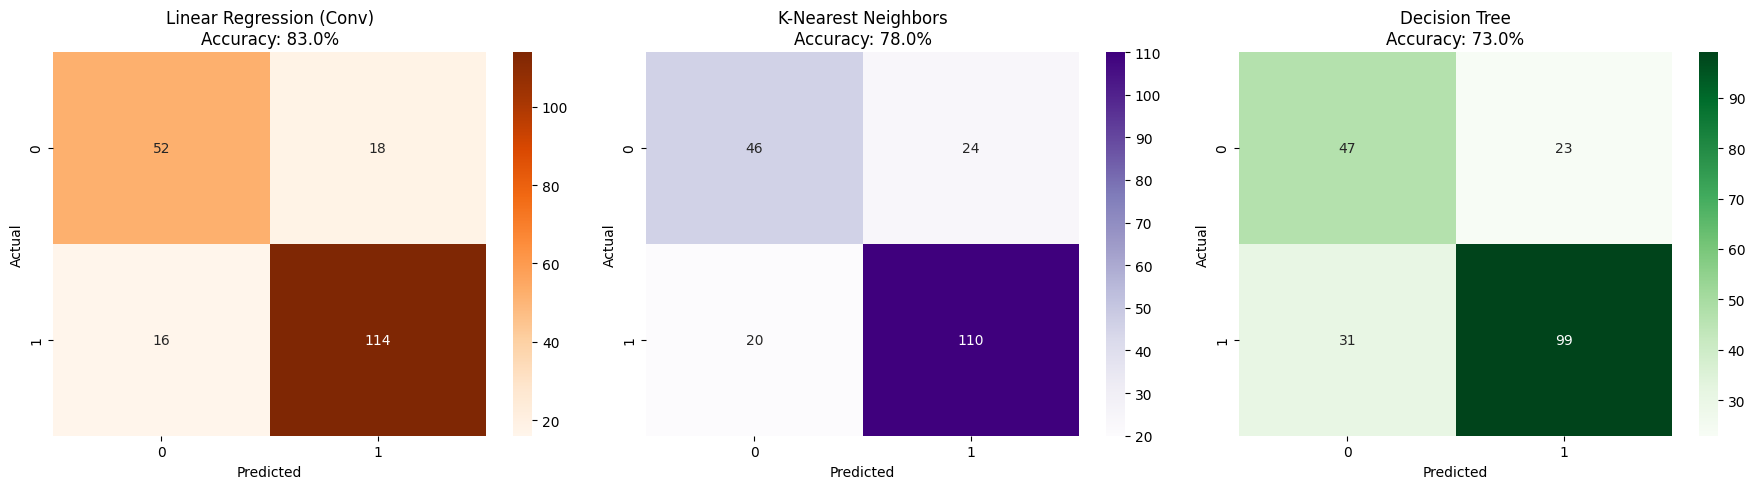

In [ ]:
# ==============================================================================
# 1. Import Library yang Dipakai
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ==============================================================================
# 2. Load Dataset dan Bikin Kolom Target Kelulusan
# ==============================================================================
# Load data rapor siswa
df = pd.read_csv('StudentsPerformance.csv')

# Bikin kolom lulus/tidak: kalau nilai math >= 60 dapet 1 (lulus), sisanya 0
df['Pass_Actual'] = df['math score'].apply(lambda x: 1 if x >= 60 else 0)
#)pemilihan atribut)
# Pisahin variabel fitur (X) dan target yang mau ditebak (y)
X = df[['reading score', 'writing score']]
y_reg = df['math score']
y_cls = df['Pass_Actual']

X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)
_, _, y_train_cls, y_test_cls = train_test_split(X, y_cls, test_size=0.2, random_state=42)

# ==============================================================================
# 3. Pemodelan dan Prediksi (Training Model)
# ==============================================================================

# --- Pendekatan Regresi (Linear Regression) ---
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train_reg)
y_pred_reg_continuous = lin_reg.predict(X_test)
y_pred_reg_converted = np.where(y_pred_reg_continuous >= 60, 1, 0)


# --- Model Klasifikasi 1 (Decision Tree) ---
dt_cls = DecisionTreeClassifier(random_state=42)
dt_cls.fit(X_train, y_train_cls)
y_pred_dt = dt_cls.predict(X_test)


# --- Model Klasifikasi 2 (KNN) ---
knn_cls = KNeighborsClassifier(n_neighbors=5)
knn_cls.fit(X_train, y_train_cls)
y_pred_knn = knn_cls.predict(X_test)

# ==============================================================================
# 4. Hitung Skor Akurasi Masing-Masing Model
# ==============================================================================
acc_linear_reg = accuracy_score(y_test_cls, y_pred_reg_converted)
acc_knn = accuracy_score(y_test_cls, y_pred_knn)
acc_decision_tree = accuracy_score(y_test_cls, y_pred_dt)

# ==============================================================================
# 5. Print Output Tabel Akurasi dan Classification Report
# ==============================================================================
print("=========================================================")
print("          TABEL PERBANDINGAN AKURASI AKHIR               ")
print("=========================================================")
print(f"1. Linear Regression (Konversi)  : {acc_linear_reg:.4f} ({acc_linear_reg*100:.1f}%)")
print(f"2. K-Nearest Neighbors (KNN)     : {acc_knn:.4f} ({acc_knn*100:.1f}%)")
print(f"3. Decision Tree                 : {acc_decision_tree:.4f} ({acc_decision_tree*100:.1f}%)")
print("=========================================================\n")

# Cetak detail report evaluasi buat ketiga model
print("=== KLASIFIKASI REPORT: LINEAR REGRESSION (KONVERSI) ===")
print(classification_report(y_test_cls, y_pred_reg_converted))

print("\n=== KLASIFIKASI REPORT: K-NEAREST NEIGHBORS ===")
print(classification_report(y_test_cls, y_pred_knn))

print("\n=== KLASIFIKASI REPORT: DECISION TREE ===")
print(classification_report(y_test_cls, y_pred_dt))

# ==============================================================================
# 6. Plot Grafik Confusion Matrix
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Heatmap buat Linear Regression
sns.heatmap(confusion_matrix(y_test_cls, y_pred_reg_converted), annot=True, fmt='d', cmap='Oranges', ax=axes[0])
axes[0].set_title(f'Linear Regression (Conv)\nAccuracy: {acc_linear_reg*100:.1f}%')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Heatmap buat KNN
sns.heatmap(confusion_matrix(y_test_cls, y_pred_knn), annot=True, fmt='d', cmap='Purples', ax=axes[1])
axes[1].set_title(f'K-Nearest Neighbors\nAccuracy: {acc_knn*100:.1f}%')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# Heatmap buat Decision Tree
sns.heatmap(confusion_matrix(y_test_cls, y_pred_dt), annot=True, fmt='d', cmap='Greens', ax=axes[2])
axes[2].set_title(f'Decision Tree\nAccuracy: {acc_decision_tree*100:.1f}%')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.show()